In [58]:
import os
import csv
import random
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter, defaultdict
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [60]:
DATA_ROOT = "/kaggle/input/datasets/malakkhaled810/adni-data/adni_nifti_preprocessed"
OUTPUT_DIR = "/kaggle/working/preprocessed_dualcnn"
CKPT_DIR   = "/kaggle/working/checkpoints_dualcnn"

os.makedirs(CKPT_DIR, exist_ok=True)

IMAGE_SIZE   = 224
N_FOLDS      = 5
BATCH_SIZE   = 32
NUM_EPOCHS   = 25
LR           = 1e-3
WEIGHT_DECAY = 1e-4 
PATIENCE     = 5
DROPOUT_RATE = 0.4 

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
fold_results    = {cls: [] for cls in CLASS_NAMES}
all_fold_ckpts  = {cls: [] for cls in CLASS_NAMES}
all_fold_models = {cls: [] for cls in CLASS_NAMES}
history_all_folds = {cls: [] for cls in CLASS_NAMES}

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes found: {CLASS_NAMES}  ({NUM_CLASSES}-way classification)")

Classes found: ['AD', 'CN', 'MCI']  (3-way classification)


In [61]:
CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
print(f"Classes found: {CLASS_NAMES}")

Classes found: ['AD', 'CN', 'MCI']


# Checking Patients & Leakage

In [62]:
patient_classes = defaultdict(set)
patient_slices = defaultdict(list)

for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    if not os.path.isdir(cls_dir):
        print(f"[WARNING] Missing class folder: {cls_dir}")
        continue
    for patient_id in os.listdir(cls_dir):
        patient_dir = os.path.join(cls_dir, patient_id)
        if not os.path.isdir(patient_dir):
            continue
        slices = [
            os.path.join(patient_dir, f)
            for f in os.listdir(patient_dir)
            if os.path.splitext(f)[1].lower() in VALID_EXTS
        ]
        if slices:
            patient_classes[patient_id].add(cls)
            patient_slices[(patient_id, cls)].extend(slices)

print(f"Total unique patients: {len(patient_classes)}")

Total unique patients: 320


In [63]:
leakage_patients = {
    pid: classes
    for pid, classes in patient_classes.items()
    if len(classes) > 1
}

print(f"\n{'='*55}")
print(f"  LEAKAGE CHECK")
print(f"{'='*55}")
if leakage_patients:
    print(f"  Patients in multiple classes (EXCLUDED): {len(leakage_patients)}")
    for pid, classes in sorted(leakage_patients.items()):
        print(f"    {pid}  ->  {sorted(classes)}")
else:
    print("  No patients in multiple classes. Dataset is clean.")

clean_patients = {
    pid: list(classes)[0]
    for pid, classes in patient_classes.items()
    if pid not in leakage_patients
}
print(f"\n  Patients kept    : {len(clean_patients)}")
print(f"  Patients excluded: {len(leakage_patients)}")


  LEAKAGE CHECK
  No patients in multiple classes. Dataset is clean.

  Patients kept    : 320
  Patients excluded: 0


# Hold-out Test Set (PATIENT-LEVEL, STRATIFIED)

In [64]:
TEST_RATIO = 0.15

class_patients = defaultdict(list)
for pid, cls in clean_patients.items():
    class_patients[cls].append(pid)

for cls in CLASS_NAMES:
    random.shuffle(class_patients[cls])

test_patients     = []
trainval_patients = []

print(f"{'='*55}")
print(f"  HOLD-OUT TEST SET (stratified by class)")
print(f"{'='*55}")

for cls in CLASS_NAMES:
    pids   = class_patients[cls]
    n_test = max(1, int(len(pids) * TEST_RATIO))
    test_patients.extend(pids[:n_test])
    trainval_patients.extend(pids[n_test:])
    print(f"  {cls}: {len(pids)} total  |  test={n_test}  |  train+val pool={len(pids)-n_test}")

assert not (set(test_patients) & set(trainval_patients)), "Test/trainval overlap!"
print(f"\n  Test patients     : {len(test_patients)}")
print(f"  Train+Val patients: {len(trainval_patients)}")
print(f"  Total             : {len(test_patients)+len(trainval_patients)}")

test_entries = []
for pid in test_patients:
    cls   = clean_patients[pid]
    label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]:
        test_entries.append((path, label, pid))

print(f"  Test slices       : {len(test_entries)}")

  HOLD-OUT TEST SET (stratified by class)
  AD: 54 total  |  test=8  |  train+val pool=46
  CN: 88 total  |  test=13  |  train+val pool=75
  MCI: 178 total  |  test=26  |  train+val pool=152

  Test patients     : 47
  Train+Val patients: 273
  Total             : 320
  Test slices       : 1261


# Preprocessing & Saving Slices

In [65]:
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_entries = []
for pid, cls in clean_patients.items():
    label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]:
        all_entries.append((path, label, pid))

fname_counts = {}

def preprocess_and_save(entries, desc="Saving"):
    for path, label, pid in tqdm(entries, desc=desc):
        cls_name = CLASS_NAMES[label]
        out_dir  = os.path.join(OUTPUT_DIR, cls_name)
        os.makedirs(out_dir, exist_ok=True)

        base  = os.path.splitext(os.path.basename(path))[0]
        key   = f"{pid}_{base}"
        fname_counts[key] = fname_counts.get(key, 0) + 1
        suffix   = f"_dup{fname_counts[key]}" if fname_counts[key] > 1 else ""
        out_path = os.path.join(out_dir, f"{key}{suffix}.pt")

        if not os.path.exists(out_path):
            img    = Image.open(path).convert("L")
            img    = img.resize((IMAGE_SIZE, IMAGE_SIZE))
            tensor = transforms.ToTensor()(img)
            tensor = (tensor * 255).byte().repeat(3, 1, 1)
            torch.save(tensor, out_path)

preprocess_and_save(all_entries, desc="Preprocessing all slices")
print(f"Done. {len(all_entries)} slices saved to {OUTPUT_DIR}")

pt_lookup = {}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(OUTPUT_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for fname in os.listdir(cls_dir):
        if fname.endswith(".pt"):
            stem = fname[:-3]
            pt_lookup[stem] = os.path.join(cls_dir, fname)

print(f"pt_lookup built: {len(pt_lookup)} entries")

Preprocessing all slices: 100%|██████████| 8512/8512 [00:26<00:00, 324.40it/s]

Done. 8512 slices saved to /kaggle/working/preprocessed_dualcnn
pt_lookup built: 8512 entries


In [66]:
pt_lookup = {}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(OUTPUT_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for fname in os.listdir(cls_dir):
        if fname.endswith(".pt"):
            stem = fname[:-3]
            pt_lookup[stem] = os.path.join(cls_dir, fname)

print(f"pt_lookup built: {len(pt_lookup)} entries")

pt_lookup built: 8512 entries


# Dataset Class & Augmentation

In [67]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

train_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

class SliceDataset(Dataset):
    """
    Identical to your original notebook.
    Loads preprocessed .pt tensors for (path, label, patient_id) entries.
    augment=True is now used during CNN training (paper uses augmentation).
    """
    def __init__(self, entries, augment=False):
        self.samples = []
        self.augment = augment
        for path, label, pid in entries:
            cls_name = CLASS_NAMES[label]
            base     = os.path.splitext(os.path.basename(path))[0]
            key      = f"{pid}_{base}"

            if key in pt_lookup:
                self.samples.append((pt_lookup[key], label, pid))
            else:
                found = False
                for dup_idx in range(2, 50):
                    dup_key = f"{key}_dup{dup_idx}"
                    if dup_key in pt_lookup:
                        self.samples.append((pt_lookup[dup_key], label, pid))
                        found = True
                        break
                if not found:
                    pass

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        pt_path, label, pid = self.samples[idx]
        tensor = torch.load(pt_path, weights_only=True).float() / 255.0
        if self.augment:
            tensor = train_augment(tensor)
        return normalize(tensor), label, pid

    def get_labels(self): return [s[1] for s in self.samples]

print("SliceDataset class defined.")

SliceDataset class defined.


# Dual-CNN Model Architecture

In [68]:
class CNN1Branch(nn.Module):
    """
    Reduced branch: 3x3 filters, halved filter counts.
    Conv(8) -> Conv(8) -> BN -> Pool -> Conv(32) -> Conv(32) -> BN -> Pool
    -> Conv(128) -> BN -> Pool -> Dropout -> Flatten -> FC(128)
    """
    def __init__(self, dropout_rate=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=0),
            nn.ReLU(inplace=True),
            nn.Conv2d(8, 8, kernel_size=3, padding=0),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(8),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(8, 32, kernel_size=3, padding=0),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=0),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 128, kernel_size=3, padding=0),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.dropout = nn.Dropout(p=dropout_rate)
        self.flatten = nn.Flatten()
        self.fc      = nn.Linear(128 * 25 * 25, 128)
        self.relu    = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.features(x)
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.relu(self.fc(x))
        return x

class CNN2Branch(nn.Module):
    """
    Reduced branch: 5x5 filters, halved filter counts.
    Conv(16) -> Conv(16) -> BN -> Pool -> Conv(64) -> Conv(64) -> BN -> Pool
    -> Conv(256) -> BN -> Pool -> Dropout -> Flatten -> FC(128)
    """
    def __init__(self, dropout_rate=0.4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, padding=0),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, kernel_size=5, padding=0),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 64, kernel_size=5, padding=0),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=5, padding=0),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 256, kernel_size=5, padding=0),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.dropout = nn.Dropout(p=dropout_rate)
        self.flatten = nn.Flatten()
        self.fc      = nn.Linear(256 * 23 * 23, 128)
        self.relu    = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.features(x)
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.relu(self.fc(x))
        return x

class DualCNN(nn.Module):
    """
    El-Assy et al. (2024) — Figure 5.
    Two parallel CNN branches concatenated -> FC(num_classes) -> Softmax.
    Input: (B, 3, 224, 224)  shared between both branches.
    """
    def __init__(self, num_classes=5, dropout_rate=0.2):
        super().__init__()
        self.branch1    = CNN1Branch(dropout_rate)
        self.branch2    = CNN2Branch(dropout_rate)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        f1  = self.branch1(x)
        f2  = self.branch2(x)
        cat = torch.cat([f1, f2], dim=1)
        return self.classifier(cat)

def build_dualcnn(num_classes=2, dropout_rate=DROPOUT_RATE):
    return DualCNN(num_classes=num_classes, dropout_rate=dropout_rate).to(device)

_dummy = torch.zeros(2, 3, 224, 224).to(device)
_model = build_dualcnn()
_out   = _model(_dummy)
total_params     = sum(p.numel() for p in _model.parameters())
trainable_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)

print("Dual-CNN — architecture verified.")
print(f"  Output shape       : {_out.shape}   (expected: [2, {NUM_CLASSES}])")
print(f"  Total params       : {total_params:,}")
print(f"  Trainable params   : {trainable_params:,}   (all trainable)")
del _dummy, _model, _out

Dual-CNN — architecture verified.
  Output shape       : torch.Size([2, 2])   (expected: [2, 3])
  Total params       : 28,171,050
  Trainable params   : 28,171,050   (all trainable)


# Training Utilities

In [69]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels, _ in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits      = model(images)
        loss        = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def patient_level_eval(model, loader):
    """
    Patient-level accuracy via soft voting (identical logic to your notebook).
    Averages softmax probabilities across all slices of a patient -> argmax.
    """
    model.eval()
    patient_probs  = defaultdict(lambda: np.zeros(2))
    patient_labels = {}

    for images, labels, pids in loader:
        images = images.to(device, non_blocking=True)
        logits = model(images)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()

        for prob, label, pid in zip(probs, labels.numpy(), pids):
            if patient_probs[pid].shape != prob.shape:
                patient_probs=np.zeros_like(prob)
            patient_probs[pid]  += prob
            patient_labels[pid]  = int(label)

    all_true, all_pred = [], []
    for pid, prob_sum in patient_probs.items():
        all_true.append(patient_labels[pid])
        all_pred.append(int(np.argmax(prob_sum)))

    acc = np.mean(np.array(all_true) == np.array(all_pred))
    return acc, all_true, all_pred

print("Training utilities defined.")

Training utilities defined.


# K-Fold Cross Validation (Train & Val)

In [70]:
trainval_by_class = defaultdict(list)
for pid in trainval_patients:
    trainval_by_class[clean_patients[pid]].append(pid)

for cls in CLASS_NAMES:
    random.shuffle(trainval_by_class[cls])

class_folds = {}
for cls in CLASS_NAMES:
    pids  = trainval_by_class[cls]
    class_folds[cls] = [pids[i::N_FOLDS] for i in range(N_FOLDS)]

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    print(f"\n{'='*65}")
    print(f"  {pos_name} vs REST  —  {N_FOLDS}-Fold CV  (Dual-CNN)")
    print(f"{'='*65}")

    for fold_idx in range(N_FOLDS):
        print(f"\n  --- Fold {fold_idx+1}/{N_FOLDS} ---")

        val_pids_fold   = []
        train_pids_fold = []
        for cls in CLASS_NAMES:
            val_pids_fold.extend(class_folds[cls][fold_idx])
            for k, chunk in enumerate(class_folds[cls]):
                if k != fold_idx:
                    train_pids_fold.extend(chunk)

        def expand(pids):
            out = []
            for pid in pids:
                cls   = clean_patients[pid]
                label = CLASS_NAMES.index(cls)
                for path in patient_slices[(pid, cls)]:
                    out.append((path, label, pid))
            return out

        def binarize(entries):
            return [(p, 1 if l == pos_class_idx else 0, pid)
                    for p, l, pid in entries]

        train_bin = binarize(expand(train_pids_fold))
        val_bin   = binarize(expand(val_pids_fold))

        train_ds = SliceDataset(train_bin, augment=True)
        val_ds   = SliceDataset(val_bin,   augment=False)

        pos_count = sum(1 for _, l, _ in train_bin if l == 1)
        neg_count = len(train_bin) - pos_count
        print(f"  Train — {pos_name}: {pos_count} | REST: {neg_count} | "
              f"Val patients: {len(val_pids_fold)}")

        total_slices  = len(train_ds)
        class_weights = torch.tensor(
            [total_slices / (2.0 * neg_count),
             total_slices / (2.0 * pos_count)],
            dtype=torch.float
        ).to(device)

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=4, pin_memory=True, persistent_workers=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=4, pin_memory=True, persistent_workers=True)

        model     = build_dualcnn(num_classes=2)
        optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        best_val_acc = 0.0
        patience_ctr = 0
        ckpt_path    = os.path.join(CKPT_DIR,
                           f"fold{fold_idx+1}_{pos_name}_vs_rest_dualcnn_best.pt")

        fold_history = {"train_loss": [], "train_acc": [],
                        "val_loss":   [], "val_acc":   []}

        for epoch in range(1, NUM_EPOCHS + 1):
            tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
            vl_loss, vl_acc = evaluate(model, val_loader, criterion)

            fold_history["train_loss"].append(tr_loss)
            fold_history["train_acc"].append(tr_acc)
            fold_history["val_loss"].append(vl_loss)
            fold_history["val_acc"].append(vl_acc)

            improved = vl_acc > best_val_acc
            if improved:
                best_val_acc = vl_acc
                patience_ctr = 0
                torch.save(model.state_dict(), ckpt_path)
            else:
                patience_ctr += 1

            print(f"  Epoch {epoch:02d}/{NUM_EPOCHS}  "
                  f"train_loss={tr_loss:.4f}  train_acc={tr_acc*100:.2f}%  "
                  f"val_loss={vl_loss:.4f}  val_acc={vl_acc*100:.2f}%"
                  + ("  ✓ saved" if improved else f"  (patience {patience_ctr}/{PATIENCE})"))

            if patience_ctr >= PATIENCE:
                print(f"  Early stopping at epoch {epoch}.")
                break

        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        pat_acc, _, _ = patient_level_eval(model, val_loader)
        print(f"\n  Fold {fold_idx+1} ({pos_name} vs REST) — "
              f"best slice val acc: {best_val_acc*100:.2f}%  "
              f"patient val acc: {pat_acc*100:.2f}%")

        fold_results[pos_name].append(pat_acc)
        all_fold_ckpts[pos_name].append(ckpt_path)
        all_fold_models[pos_name].append(model.state_dict().copy())
        history_all_folds[pos_name].append(fold_history)

        del model, train_ds, val_ds
        torch.cuda.empty_cache()

    mean_acc = np.mean(fold_results[pos_name]) * 100
    std_acc  = np.std(fold_results[pos_name])  * 100
    print(f"\n  {pos_name} vs REST — {N_FOLDS}-Fold CV Patient Acc: "
          f"{mean_acc:.2f}% ± {std_acc:.2f}%")

print("\n\nAll folds done.")


  AD vs REST  —  5-Fold CV  (Dual-CNN)

  --- Fold 1/5 ---
  Train — AD: 950 | REST: 4808 | Val patients: 56
  Epoch 01/25  train_loss=2.1191  train_acc=61.72%  val_loss=0.4580  val_acc=80.91%  ✓ saved
  Epoch 02/25  train_loss=0.5919  train_acc=70.34%  val_loss=0.4141  val_acc=81.45%  ✓ saved
  Epoch 03/25  train_loss=0.5621  train_acc=72.54%  val_loss=0.5156  val_acc=73.95%  (patience 1/5)
  Epoch 04/25  train_loss=0.5424  train_acc=73.13%  val_loss=1.0055  val_acc=46.89%  (patience 2/5)
  Epoch 05/25  train_loss=0.5242  train_acc=75.65%  val_loss=0.6703  val_acc=67.05%  (patience 3/5)
  Epoch 06/25  train_loss=0.4709  train_acc=78.71%  val_loss=0.5001  val_acc=75.62%  (patience 4/5)
  Epoch 07/25  train_loss=0.4343  train_acc=80.81%  val_loss=0.6781  val_acc=65.04%  (patience 5/5)
  Early stopping at epoch 7.

  Fold 1 (AD vs REST) — best slice val acc: 81.45%  patient val acc: 80.36%

  --- Fold 2/5 ---
  Train — AD: 982 | REST: 4809 | Val patients: 55
  Epoch 01/25  train_loss=1.

# Curves

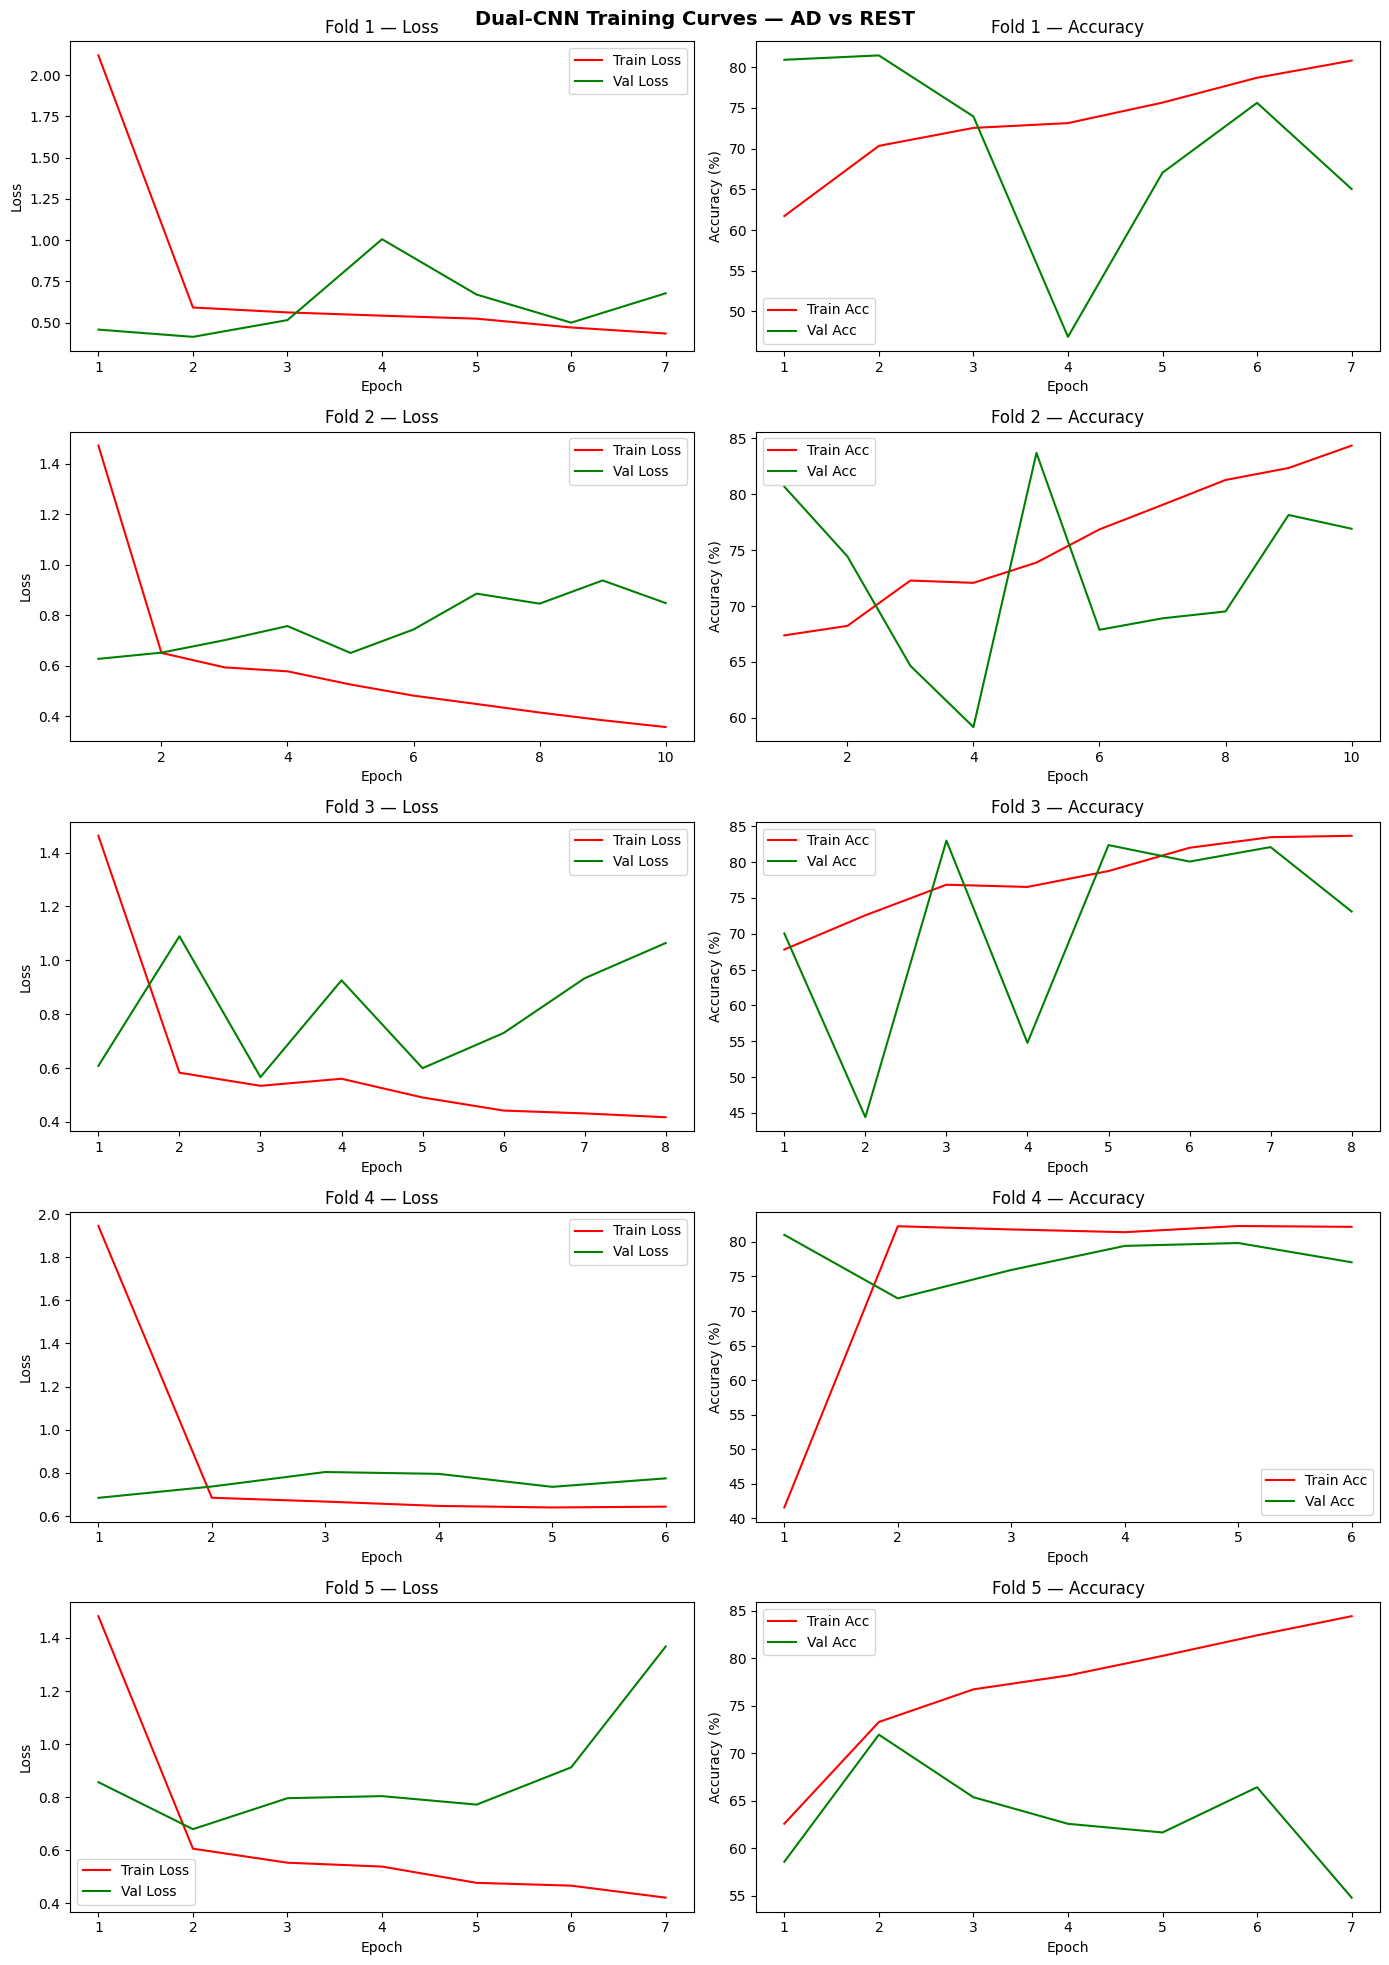

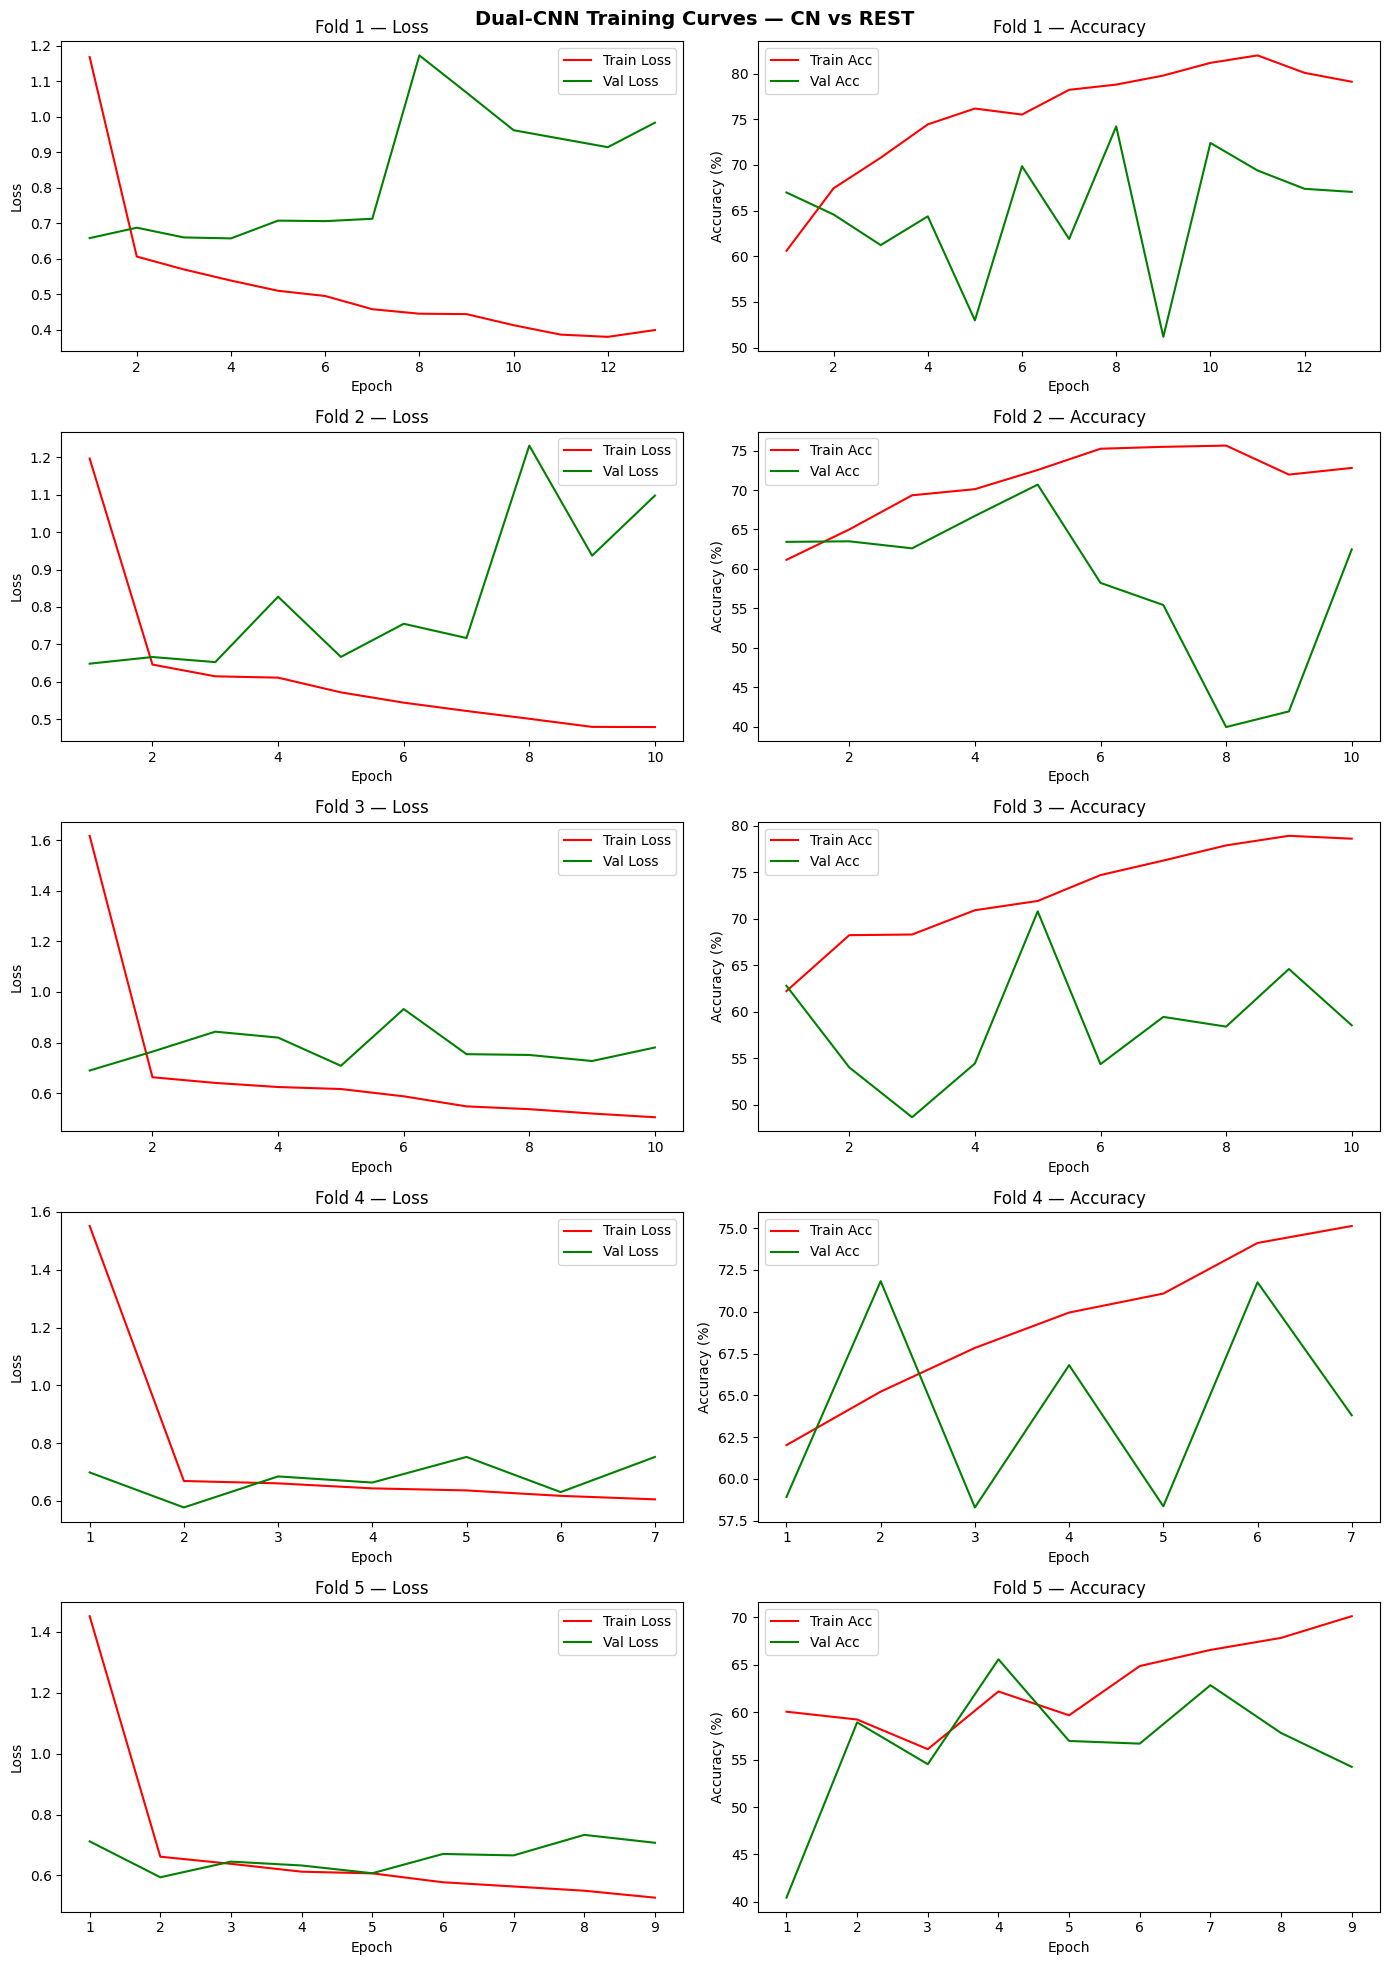

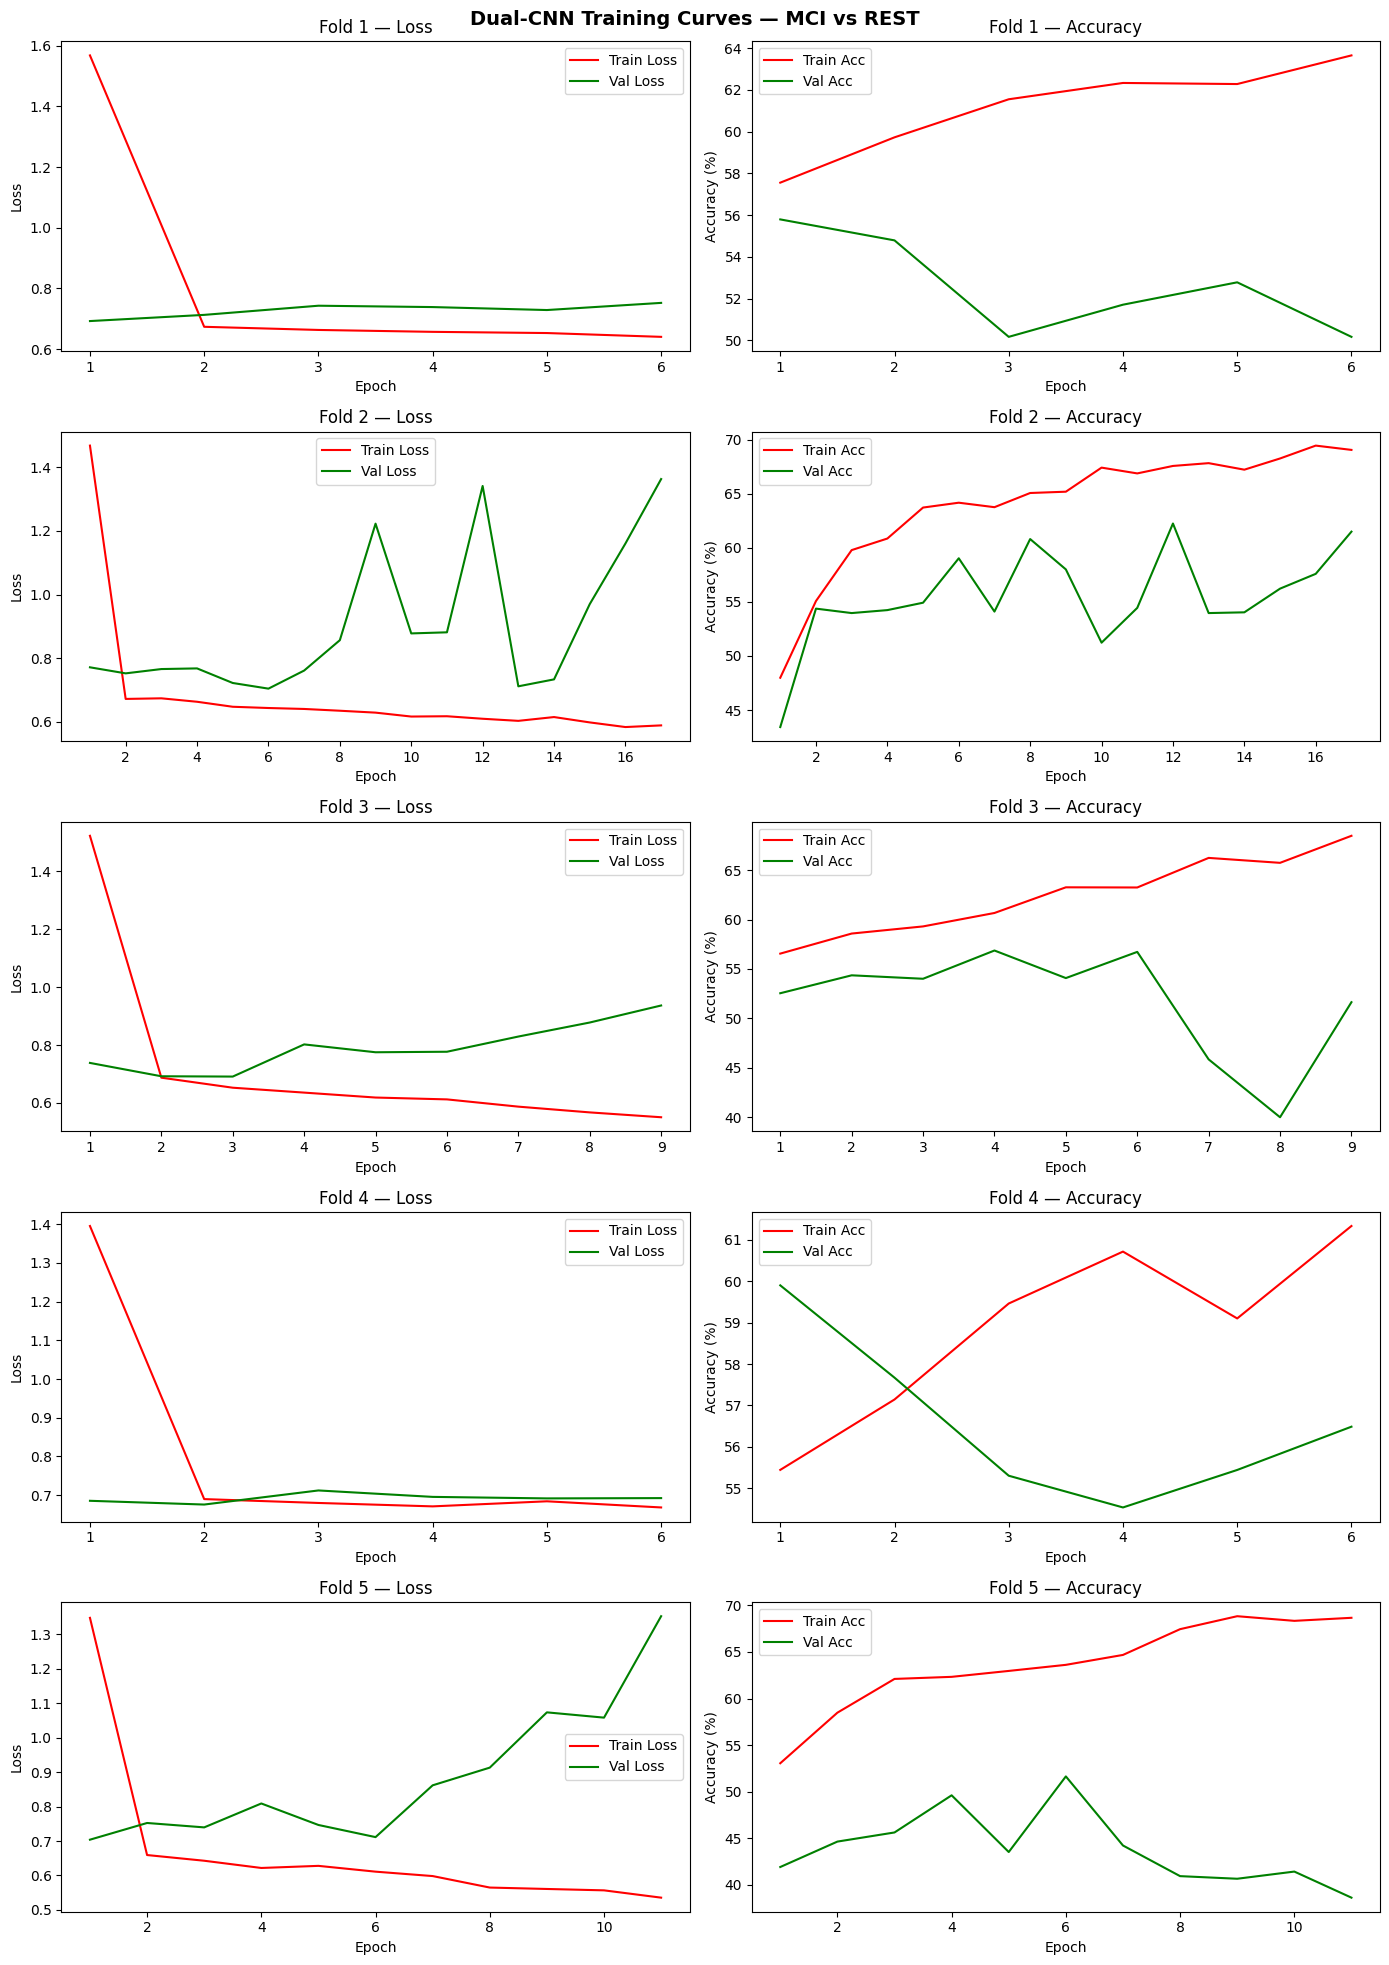

In [71]:
for pos_name, folds_hist in history_all_folds.items():
    fig, axes = plt.subplots(N_FOLDS, 2, figsize=(14, 4 * N_FOLDS))
    fig.suptitle(f"Dual-CNN Training Curves — {pos_name} vs REST",
                 fontsize=14, fontweight='bold')

    for fold_idx, hist in enumerate(folds_hist):
        epochs = range(1, len(hist["train_loss"]) + 1)

        axes[fold_idx][0].plot(epochs, hist["train_loss"], label="Train Loss", color="red")
        axes[fold_idx][0].plot(epochs, hist["val_loss"],   label="Val Loss",   color="green")
        axes[fold_idx][0].set_title(f"Fold {fold_idx+1} — Loss")
        axes[fold_idx][0].set_xlabel("Epoch"); axes[fold_idx][0].set_ylabel("Loss")
        axes[fold_idx][0].legend()

        axes[fold_idx][1].plot(epochs, [a*100 for a in hist["train_acc"]],
                               label="Train Acc", color="red")
        axes[fold_idx][1].plot(epochs, [a*100 for a in hist["val_acc"]],
                               label="Val Acc",   color="green")
        axes[fold_idx][1].set_title(f"Fold {fold_idx+1} — Accuracy")
        axes[fold_idx][1].set_xlabel("Epoch"); axes[fold_idx][1].set_ylabel("Accuracy (%)")
        axes[fold_idx][1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f"dualcnn_curves_{pos_name}_vs_rest.png"), dpi=150)
    plt.show()

# Weighted Ensemble Evaluation On Hold-Out Test Set

  WEIGHTED ENSEMBLE — HOLD-OUT TEST EVALUATION (Patient-Level)
  Model: Dual-CNN  (OvR)

  AD vs REST
    Fold 1: val_acc=80.36%  weight=0.2004
    Fold 2: val_acc=85.45%  weight=0.2131
    Fold 3: val_acc=85.19%  weight=0.2124
    Fold 4: val_acc=79.63%  weight=0.1986
    Fold 5: val_acc=70.37%  weight=0.1755

  Weighted Ensemble Test Acc (AD vs REST): 72.34%  [47 patients]
              precision    recall  f1-score   support

        REST       0.82      0.85      0.84        39
          AD       0.14      0.12      0.13         8

    accuracy                           0.72        47
   macro avg       0.48      0.49      0.48        47
weighted avg       0.71      0.72      0.72        47



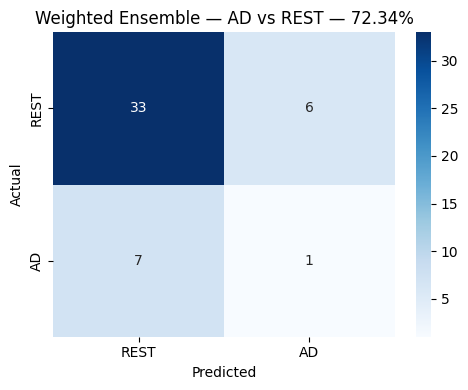


  CN vs REST
    Fold 1: val_acc=73.21%  weight=0.2071
    Fold 2: val_acc=67.27%  weight=0.1903
    Fold 3: val_acc=72.22%  weight=0.2043
    Fold 4: val_acc=72.22%  weight=0.2043
    Fold 5: val_acc=68.52%  weight=0.1939

  Weighted Ensemble Test Acc (CN vs REST): 72.34%  [47 patients]
              precision    recall  f1-score   support

        REST       0.74      0.94      0.83        34
          CN       0.50      0.15      0.24        13

    accuracy                           0.72        47
   macro avg       0.62      0.55      0.53        47
weighted avg       0.68      0.72      0.67        47



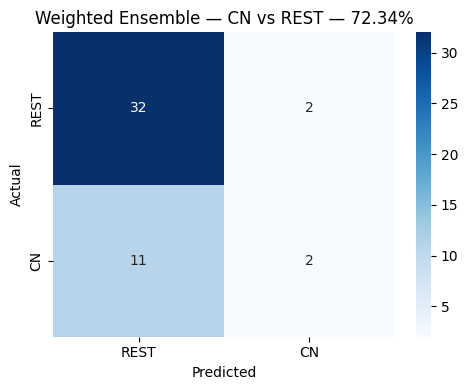


  MCI vs REST
    Fold 1: val_acc=53.57%  weight=0.1863
    Fold 2: val_acc=63.64%  weight=0.2213
    Fold 3: val_acc=59.26%  weight=0.2061
    Fold 4: val_acc=61.11%  weight=0.2125
    Fold 5: val_acc=50.00%  weight=0.1739

  Weighted Ensemble Test Acc (MCI vs REST): 55.32%  [47 patients]
              precision    recall  f1-score   support

        REST       0.50      0.38      0.43        21
         MCI       0.58      0.69      0.63        26

    accuracy                           0.55        47
   macro avg       0.54      0.54      0.53        47
weighted avg       0.54      0.55      0.54        47



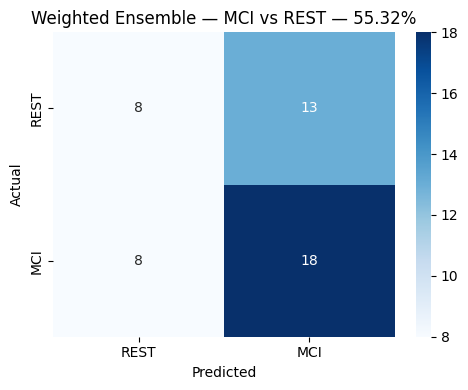

In [72]:
print(f"{'='*65}")
print(f"  WEIGHTED ENSEMBLE — HOLD-OUT TEST EVALUATION (Patient-Level)")
print(f"  Model: Dual-CNN  (OvR)")
print(f"{'='*65}")

final_results = {}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    binary_names = ["REST", pos_name]

    test_bin = [(p, 1 if l == pos_class_idx else 0, pid)
                for p, l, pid in test_entries]
    test_ds     = SliceDataset(test_bin, augment=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=4, pin_memory=True, persistent_workers=True)

    fold_accs    = np.array(fold_results[pos_name])
    fold_weights = fold_accs / fold_accs.sum()

    print(f"\n  {pos_name} vs REST")
    for fi, (acc, w) in enumerate(zip(fold_accs, fold_weights)):
        print(f"    Fold {fi+1}: val_acc={acc*100:.2f}%  weight={w:.4f}")

    weighted_probs = np.zeros((len(test_ds), 2))

    for fi, (state_dict, w) in enumerate(zip(all_fold_models[pos_name], fold_weights)):
        fold_model = build_dualcnn(num_classes=2)
        fold_model.load_state_dict(state_dict)
        fold_model.eval()

        all_probs = []
        with torch.no_grad():
            for images, labels, pids in test_loader:
                images = images.to(device, non_blocking=True)
                probs  = torch.softmax(fold_model(images), dim=1).cpu().numpy()
                all_probs.append(probs)
        weighted_probs += w * np.vstack(all_probs)
        del fold_model
        torch.cuda.empty_cache()

    test_pids_list  = [s[2] for s in test_ds.samples]
    test_lbls_list  = [s[1] for s in test_ds.samples]

    patient_probs  = defaultdict(lambda: np.zeros(2))
    patient_labels = {}
    for wp, label, pid in zip(weighted_probs, test_lbls_list, test_pids_list):
        patient_probs[pid]  += wp
        patient_labels[pid]  = int(label)

    all_true, all_pred = [], []
    for pid, wp_sum in patient_probs.items():
        all_true.append(patient_labels[pid])
        all_pred.append(int(np.argmax(wp_sum)))

    pat_acc = np.mean(np.array(all_true) == np.array(all_pred))
    print(f"\n  Weighted Ensemble Test Acc ({pos_name} vs REST): "
          f"{pat_acc*100:.2f}%  [{len(patient_probs)} patients]")
    print(classification_report(all_true, all_pred, target_names=binary_names))

    cm = confusion_matrix(all_true, all_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=binary_names, yticklabels=binary_names)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"Weighted Ensemble — {pos_name} vs REST — {pat_acc*100:.2f}%")
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f"cm_ensemble_{pos_name}_vs_rest_dualcnn.png"), dpi=150)
    plt.show()

    final_results[pos_name] = {
        "patient_test_acc": pat_acc,
        "cv_mean_acc":      float(np.mean(fold_accs)),
        "cv_std_acc":       float(np.std(fold_accs)),
        "fold_weights":     fold_weights.tolist(),
    }

    del test_ds
    torch.cuda.empty_cache()

# Summary & Saving Results

In [117]:
import os
import shutil
from IPython.display import FileLink, display

print("="*60)
print("Packaging all files into a single ZIP...")
print("="*60)

import joblib
save_path = os.path.join(CKPT_DIR, 'DualCNN_model_final.pkl')
joblib.dump(DualCNN, save_path)

zip_path = "/kaggle/temp/all_project_outputs.zip"
os.makedirs("/kaggle/temp", exist_ok=True)
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', '/kaggle/working')

final_zip_path = "/kaggle/working/all_project_outputs.zip"
shutil.move(zip_path, final_zip_path)

print("\n✅ Done! Click the link below to download everything in one file:")
display(FileLink("all_project_outputs.zip"))

Packaging all files into a single ZIP...

✅ Done! Click the link below to download everything in one file:


/kaggle/working/all_project_outputs.zip

In [121]:
print(f"\n{'='*65}")
print(f"  FINAL SUMMARY — DUAL-CNN WEIGHTED ENSEMBLE (OvR)")
print(f"{'='*65}")
print(f"  {'Class':<8} {'CV Acc (mean±std)':<24} {'Ensemble Test Acc'}")
print(f"  {'-'*55}")

for cls, res in final_results.items():
    cv_str   = f"{res['cv_mean_acc']*100:.2f}% ± {res['cv_std_acc']*100:.2f}%"
    test_str = f"{res['patient_test_acc']*100:.2f}%"
    print(f"  {cls:<8} {cv_str:<24} {test_str}")

csv_path = os.path.join(CKPT_DIR, "results_dualcnn_ovr_ensemble.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "class", "cv_mean_acc_%", "cv_std_%", "ensemble_test_acc_%", "fold_weights"
    ])
    writer.writeheader()
    for cls, res in final_results.items():
        writer.writerow({
            "class":               cls,
            "cv_mean_acc_%":       round(res["cv_mean_acc"] * 100, 2),
            "cv_std_%":            round(res["cv_std_acc"]  * 100, 2),
            "ensemble_test_acc_%": round(res["patient_test_acc"] * 100, 2),
            "fold_weights":        str([round(w, 4) for w in res["fold_weights"]]),
        })

print(f"\n  Results saved -> {csv_path}")


  FINAL SUMMARY — DUAL-CNN WEIGHTED ENSEMBLE (OvR)
  Class    CV Acc (mean±std)        Ensemble Test Acc
  -------------------------------------------------------
  AD       80.20% ± 5.47%           72.34%
  CN       70.69% ± 2.34%           72.34%
  MCI      57.52% ± 5.01%           55.32%

  Results saved -> /kaggle/working/checkpoints_dualcnn/results_dualcnn_ovr_ensemble.csv


# XAI

# Grad-Cam

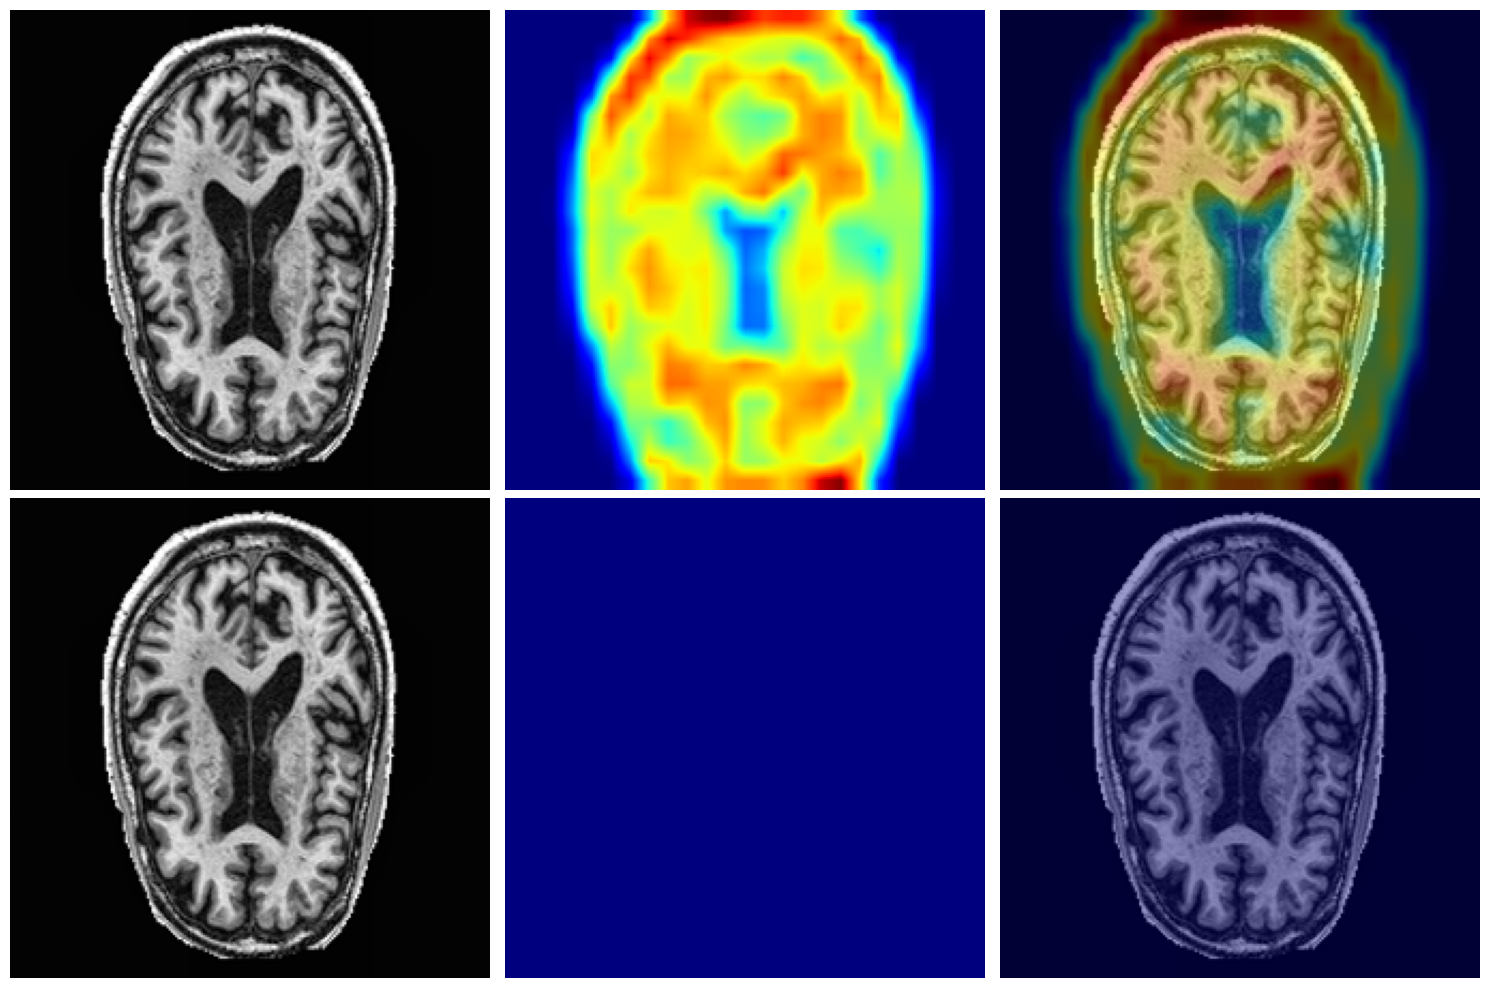

In [137]:
import cv2

def apply_gradcam(image_path, class_idx=0, fold_idx=0, alpha=0.4):
    pos_name = CLASS_NAMES[class_idx]

    model = build_dualcnn(num_classes=2, dropout_rate=DROPOUT_RATE)
    model.load_state_dict(all_fold_models[pos_name][fold_idx])
    model.to(device)
    model.eval()

    img_pil = Image.open(image_path).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    img_np  = np.array(img_pil)                      
    tensor  = normalize(transforms.ToTensor()(img_pil).repeat(3, 1, 1))
    inp     = tensor.unsqueeze(0).to(device)          
    inp.requires_grad_(False)

    store = {}

    def make_hooks(branch_name, branch_module):
        """Register forward + backward hooks on the last Conv2d of a branch."""
        last_conv = None
        for layer in branch_module.features:
            if isinstance(layer, nn.Conv2d):
                last_conv = layer
        assert last_conv is not None, f"No Conv2d found in {branch_name}"

        def fwd_hook(module, input, output):
            store[f"{branch_name}_fmap"] = output    

        def bwd_hook(module, grad_in, grad_out):
            store[f"{branch_name}_grad"] = grad_out[0]   

        h1 = last_conv.register_forward_hook(fwd_hook)
        h2 = last_conv.register_full_backward_hook(bwd_hook)
        return h1, h2

    h1a, h1b = make_hooks("branch1", model.branch1)
    h2a, h2b = make_hooks("branch2", model.branch2)

    model.zero_grad()
    logits = model(inp)                               
    score  = logits[0, class_idx]
    score.backward()

    for h in (h1a, h1b, h2a, h2b):
        h.remove()

    def grad_cam_from_store(key):
        fmap = store[f"{key}_fmap"].detach().cpu().squeeze(0) 
        grad = store[f"{key}_grad"].detach().cpu().squeeze(0) 
        weights = grad.mean(dim=(1, 2))                       
        cam = (weights[:, None, None] * fmap).sum(dim=0)     
        cam = torch.clamp(cam, min=0).numpy()
        cam = cv2.resize(cam, (IMAGE_SIZE, IMAGE_SIZE))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.astype(np.float32)

    cam1 = grad_cam_from_store("branch1")
    cam2 = grad_cam_from_store("branch2")

    def overlay(base_gray, cam):
        """Return an RGB overlay of a heatmap on a grayscale image."""
        base_rgb  = cv2.cvtColor(base_gray, cv2.COLOR_GRAY2BGR)
        heatmap   = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
        blended   = cv2.addWeighted(base_rgb, 1 - alpha, heatmap, alpha, 0)
        return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)

    ov1 = overlay(img_np, cam1)
    ov2 = overlay(img_np, cam2)
    cam_avg = (cam1 + cam2) / 2.0
    ov_avg  = overlay(img_np, cam_avg)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"Grad-CAM  —  class: {pos_name}  (fold {fold_idx})",
                 fontsize=13, fontweight='bold')

    axes[0].imshow(img_np, cmap='gray')
    axes[0].set_title("Original")
    axes[0].axis('off')

    axes[1].imshow(ov1)
    axes[1].set_title("Branch 1  (3×3 conv)")
    axes[1].axis('off')

    axes[2].imshow(ov2)
    axes[2].set_title("Branch 2  (5×5 conv)")
    axes[2].axis('off')

    axes[3].imshow(ov_avg)
    axes[3].set_title("Average of both branches")
    axes[3].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f"gradcam_{pos_name}_fold{fold_idx}.png"), dpi=150)
    plt.show()

    return cam1, cam2

test_image = test_entries[10][0]
cam1, cam2 = apply_gradcam(test_image, class_idx=0)

# LIME

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

IndexError: index 2 is out of bounds for axis 0 with size 2

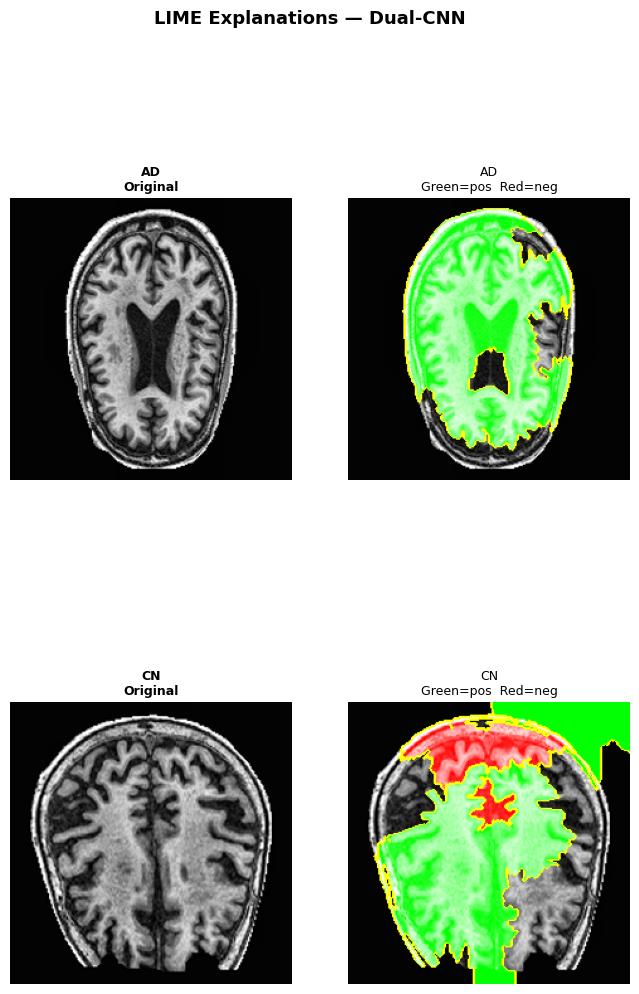

In [141]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

fig, axes = plt.subplots(2, 2, figsize=(8, NUM_CLASSES * 4))
fig.suptitle("LIME Explanations — Dual-CNN", fontsize=13, fontweight='bold')

def lime_predict_fn(images_np):
    batch = []
    for img in images_np:
        pil = Image.fromarray(img).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
        t   = normalize(transforms.ToTensor()(pil).repeat(3, 1, 1))
        batch.append(t)
    batch_t = torch.stack(batch).to(device)
    with torch.no_grad():
        logits = xai_model(batch_t)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
    return probs

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    sample = next((e for e in test_entries if e[1] == cls_idx), None)
    if sample is None:
        continue

    path, lbl, pid = sample
    img_pil  = Image.open(path).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    img_rgb  = np.stack([np.array(img_pil)] * 3, axis=-1).astype(np.uint8)

    explainer   = lime_image.LimeImageExplainer(random_state=SEED)
    explanation = explainer.explain_instance(
        img_rgb, lime_predict_fn,
        top_labels=NUM_CLASSES,
        hide_color=0,
        num_samples=500,
        random_seed=SEED,
    )
    lime_img, mask = explanation.get_image_and_mask(
        label=cls_idx, positive_only=False, num_features=10, hide_rest=False
    )

    axes[cls_idx][0].imshow(img_rgb)
    axes[cls_idx][0].set_title(f"{cls_name}\nOriginal", fontsize=9, fontweight='bold')
    axes[cls_idx][0].axis('off')

    axes[cls_idx][1].imshow(mark_boundaries(lime_img, mask))
    axes[cls_idx][1].set_title(f"{cls_name}\nGreen=pos  Red=neg", fontsize=9)
    axes[cls_idx][1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "dualcnn_lime.png"), dpi=150)
plt.show()

# Saliency

In [ ]:
def compute_saliency(image_path, class_idx=0, fold_idx=0):
    pos_name = CLASS_NAMES[class_idx]

    model = build_dualcnn(num_classes=2, dropout_rate=DROPOUT_RATE)
    model.load_state_dict(all_fold_models[pos_name][fold_idx])
    model.to(device)
    model.eval()

    img_pil = Image.open(image_path).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    img_np  = np.array(img_pil)
    tensor  = normalize(transforms.ToTensor()(img_pil).repeat(3, 1, 1))
    inp     = tensor.unsqueeze(0).to(device)
    inp.requires_grad_(True)

    model.zero_grad()
    logits = model(inp)
    score  = logits[0, class_idx]
    score.backward()

    saliency = inp.grad.detach().cpu().squeeze(0) 
    saliency = saliency.abs().max(dim=0).values
    saliency = saliency.numpy()
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Saliency Map  —  class: {pos_name}  (fold {fold_idx})",
                 fontsize=13, fontweight='bold')

    axes[0].imshow(img_np, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(saliency, cmap='hot')
    axes[1].set_title(f'Saliency — {pos_name}')
    axes[1].axis('off')

    axes[2].imshow(img_np, cmap='gray', alpha=0.6)
    axes[2].imshow(saliency, cmap='hot', alpha=0.4)
    axes[2].set_title('Saliency Overlay')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f'saliency_{pos_name}_fold{fold_idx}.png'), dpi=150)
    plt.show()

    return saliency

test_image = test_entries[0][0]
saliency   = compute_saliency(test_image, class_idx=0, fold_idx=0)

# Occlusion Sensitivity

IndexError: index 2 is out of bounds for axis 0 with size 2

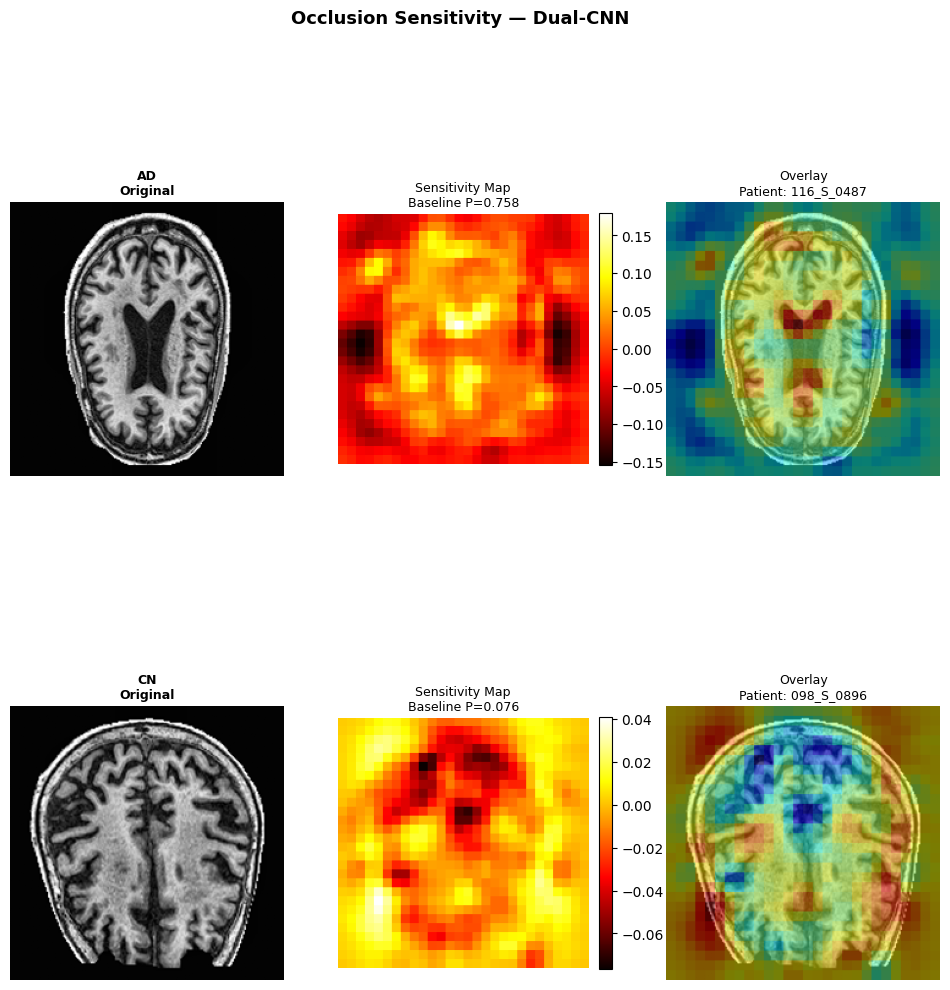

In [147]:
def occlusion_sensitivity(image_tensor, model, target_class,
                           patch_size=16, stride=8, occlude_value=0.0):
    C, H, W  = image_tensor.shape
    sens_map = np.zeros((H, W), dtype=np.float32)
    count    = np.zeros((H, W), dtype=np.float32)

    with torch.no_grad():
        base_logits = model(image_tensor.unsqueeze(0).to(device))
        base_prob   = torch.softmax(base_logits, dim=1)[0, target_class].item()

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            occluded = image_tensor.clone()
            occluded[:, y:y+patch_size, x:x+patch_size] = occlude_value
            with torch.no_grad():
                occ_logits = model(occluded.unsqueeze(0).to(device))
                occ_prob   = torch.softmax(occ_logits, dim=1)[0, target_class].item()
            drop = base_prob - occ_prob
            sens_map[y:y+patch_size, x:x+patch_size] += drop
            count   [y:y+patch_size, x:x+patch_size] += 1

    sens_map /= np.maximum(count, 1)
    return sens_map, base_prob

fig, axes = plt.subplots(2, 3, figsize=(12, NUM_CLASSES * 4))
fig.suptitle("Occlusion Sensitivity — Dual-CNN", fontsize=13, fontweight='bold')

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    sample = next((e for e in test_entries if e[1] == cls_idx), None)
    if sample is None:
        continue

    path, lbl, pid = sample
    img_pil    = Image.open(path).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    img_rgb    = np.stack([np.array(img_pil)] * 3, axis=-1).astype(np.float32) / 255.0
    img_tensor = normalize(transforms.ToTensor()(img_pil).repeat(3, 1, 1))

    sens_map, base_prob = occlusion_sensitivity(
        img_tensor, xai_model, cls_idx, patch_size=16, stride=8
    )
    sens_norm = (sens_map - sens_map.min()) / (sens_map.max() - sens_map.min() + 1e-8)

    axes[cls_idx][0].imshow(img_rgb)
    axes[cls_idx][0].set_title(f"{cls_name}\nOriginal", fontsize=9, fontweight='bold')
    axes[cls_idx][0].axis('off')

    im = axes[cls_idx][1].imshow(sens_map, cmap="hot")
    axes[cls_idx][1].set_title(f"Sensitivity Map\nBaseline P={base_prob:.3f}", fontsize=9)
    axes[cls_idx][1].axis('off')
    plt.colorbar(im, ax=axes[cls_idx][1], fraction=0.046, pad=0.04)

    axes[cls_idx][2].imshow(img_rgb)
    axes[cls_idx][2].imshow(sens_norm, cmap="jet", alpha=0.5)
    axes[cls_idx][2].set_title(f"Overlay\nPatient: {pid}", fontsize=9)
    axes[cls_idx][2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "dualcnn_occlusion.png"), dpi=150)
plt.show()